#**Analyzing the Impact of Location Factors on Housing Prices Using Linear Regression**

The dataset contains detailed real estate information used to analyze factors that influence housing prices.It features the transaction date, the age of the house, the distance to the nearest MRT station, and the number of convenience stores within the vicinity, factors known to impact accessibility and desirability of a location. It also provides the latitude and longitude coordinates of each property, allowing analysis of spatial trends. The target variable, house price per unit area, represents the property’s market value and serves as the output to be predicted using linear regression.
:
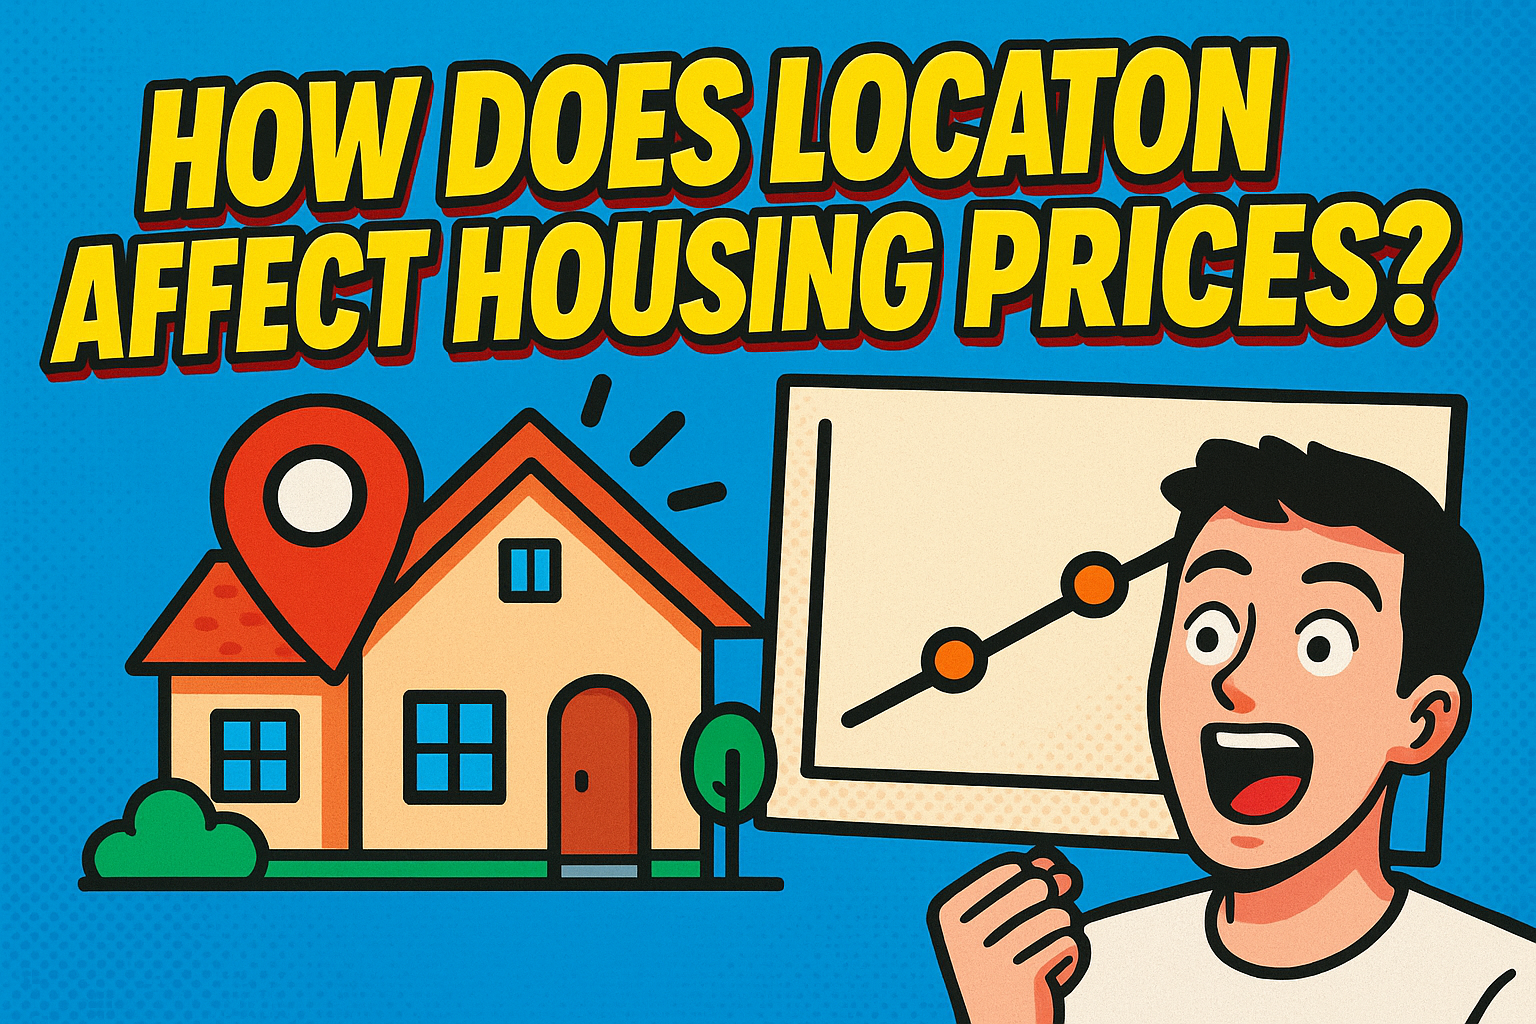



#1. Import Libraries
- These are the libraries used to complete Linear Regression data analytics.

In [ ]:
#Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model development
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Diagnostics
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Optional (for regularization models)
from sklearn.linear_model import RidgeCV, LassoCV

#2. Read Data Source
- Import/read the dataset (Real Estate Price Prediction)

In [ ]:
#Load the dataset
df = pd.read_csv("Real estate.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Check column info
print("\nDataset info:")
print(df.info())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Summary statistics
print("\nStatistical summary:")
print(df.describe())

First 5 rows of the dataset:
   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3

#2.1. Clean the Dataset
- Renaming each column for proper documentation and removing the columns that are not needed.

In [ ]:
df = df.rename(columns={
    "X1 transaction date": "transaction_date",
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "distance_MRT",
    "X4 number of convenience stores": "num_stores",
    "X5 latitude": "latitude",
    "X6 longitude": "longitude",
    "Y house price of unit area": "price_of_unit_area"
})

df = df.drop(columns=["No"])

df.head()

,transaction_date,house_age,distance_MRT,num_stores,latitude,longitude,price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


#3. Check the Predictor
- Define the features and target

In [ ]:
# Distance Squared
df['distance_MRT_sq'] = df['distance_MRT'] ** 2
# Age Squared
df['house_age_sq'] = df['house_age'] ** 2
# Interaction Term
df['MRT_stores_interact'] = df['distance_MRT'] * df['num_stores']

features_to_remove = ['transaction_date', 'latitude', 'longitude']

x = df.drop(columns=features_to_remove + ['price_of_unit_area'])
x

,house_age,distance_MRT,num_stores,distance_MRT_sq,house_age_sq,MRT_stores_interact
0,32.0,84.87882,10,7.204414e+03,1024.00,848.78820
1,19.5,306.59470,9,9.400031e+04,380.25,2759.35230
2,13.3,561.98450,5,3.158266e+05,176.89,2809.92250
3,13.3,561.98450,5,3.158266e+05,176.89,2809.92250
4,5.0,390.56840,5,1.525437e+05,25.00,1952.84200
...,...,...,...,...,...,...
409,13.7,4082.01500,0,1.666285e+07,187.69,0.00000
410,5.6,90.45606,9,8.182299e+03,31.36,814.10454
411,18.8,390.96960,7,1.528572e+05,353.44,2736.78720
412,8.1,104.81010,5,1.098516e+04,65.61,524.05050


In [ ]:
y = df['price_of_unit_area']

#4. Slice the Data for Training
- Split dataset into training and testing sets

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit the scaler on the training data and transform it
# (The model learns how big/small the numbers are from the training set only)
x_train_scaled = scaler.fit_transform(x_train)

# 3. Transform the testing data
x_test_scaled = scaler.transform(x_test)

print("✅ Data scaled successfully. Run the next block to train the new model.")

✅ Data scaled successfully. Run the next block to train the new model.


In [ ]:
#80% of the data set for featured value of X
x_train

,house_age,distance_MRT,num_stores,distance_MRT_sq,house_age_sq,MRT_stores_interact
192,43.8,57.58945,7,3.316545e+03,1918.44,403.12615
234,8.0,2216.61200,4,4.913369e+06,64.00,8866.44800
5,7.1,2175.03000,3,4.730756e+06,50.41,6525.09000
45,36.6,488.81930,8,2.389443e+05,1339.56,3910.55440
245,7.5,639.61980,5,4.091135e+05,56.25,3198.09900
...,...,...,...,...,...,...
71,35.5,640.73910,3,4.105466e+05,1260.25,1922.21730
106,17.2,189.51810,8,3.591711e+04,295.84,1516.14480
270,10.8,252.58220,1,6.379777e+04,116.64,252.58220
348,4.6,259.66070,6,6.742368e+04,21.16,1557.96420


In [ ]:
#20% of training data of the variables
x_test

,house_age,distance_MRT,num_stores,distance_MRT_sq,house_age_sq,MRT_stores_interact
358,1.1,193.5845,6,3.747496e+04,1.21,1161.5070
350,13.2,492.2313,5,2.422917e+05,174.24,2461.1565
373,0.0,274.0144,1,7.508389e+04,0.00,274.0144
399,12.7,170.1289,1,2.894384e+04,161.29,170.1289
369,20.2,2185.1280,3,4.774784e+06,408.04,6555.3840
...,...,...,...,...,...,...
31,29.6,769.4034,7,5.919816e+05,876.16,5385.8238
283,33.5,1978.6710,2,3.915139e+06,1122.25,3957.3420
157,16.1,815.9314,4,6.657440e+05,259.21,3263.7256
203,15.6,289.3248,5,8.370884e+04,243.36,1446.6240


In [ ]:
#80% of training data of target variable Diagnosis Column
y_train

,price_of_unit_area
192,42.7
234,23.9
5,32.1
45,38.3
245,40.8
...,...
71,40.8
106,47.1
270,117.5
348,53.7


In [ ]:
#20% of testing data of target variable which is Diagnostic Column
#to delete the column of index y_test.values
y_test

,price_of_unit_area
358,45.1
350,42.3
373,52.2
399,37.3
369,22.8
...,...
31,25.0
283,23.5
157,35.6
203,46.1


#5. Build Model
- Training the linear regression model

In [ ]:
from sklearn.linear_model import RidgeCV

# Define alpha values for the model to test
alphas_to_test = [0.1, 1.0, 10.0, 100.0]

# 1. Initialize and train the RidgeCV model on the SCALED data
ridge_model = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_model.fit(x_train_scaled, y_train) # Use the SCALED features

# 2. Predict using the new Ridge model on SCALED test data
predicted_value_ridge = ridge_model.predict(x_test_scaled)

print(f"✅ Ridge model trained with optimal alpha: {ridge_model.alpha_:.4f}")
print("New prediction variable is 'predicted_value_ridge'.")

✅ Ridge model trained with optimal alpha: 1.0000
New prediction variable is 'predicted_value_ridge'.


#6. Predicting
- Predict on the test set, create a dataframe with actual and predicted values, and combining the test features with the results

In [ ]:
# Predict on the test set
predicted_value = model.predict(x_test)

# Create a DataFrame with actual vs predicted values
results_df = pd.DataFrame({
    'Actual': y_test.values,       # actual target values
    'Predicted': predicted_value,  # predicted values from Linear Regression
    'Error': y_test.values - predicted_value
})

# Combine the test features (X_test) with the results_df
test_results_df = pd.concat([x_test.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)

# Display the final DataFrame
display(test_results_df)

,house_age,distance_MRT,num_stores,distance_MRT_sq,house_age_sq,MRT_stores_interact,Actual,Predicted,Error
0,1.1,193.5845,6,3.747496e+04,1.21,1161.5070,45.1,54.723958,-9.623958
1,13.2,492.2313,5,2.422917e+05,174.24,2461.1565,42.3,41.833850,0.466150
2,0.0,274.0144,1,7.508389e+04,0.00,274.0144,52.2,50.294912,1.905088
3,12.7,170.1289,1,2.894384e+04,161.29,170.1289,37.3,42.764253,-5.464253
4,20.2,2185.1280,3,4.774784e+06,408.04,6555.3840,22.8,22.021108,0.778892
...,...,...,...,...,...,...,...,...,...
78,29.6,769.4034,7,5.919816e+05,876.16,5385.8238,25.0,35.756540,-10.756540
79,33.5,1978.6710,2,3.915139e+06,1122.25,3957.3420,23.5,23.124907,0.375093
80,16.1,815.9314,4,6.657440e+05,259.21,3263.7256,35.6,36.033651,-0.433651
81,15.6,289.3248,5,8.370884e+04,243.36,1446.6240,46.1,43.488823,2.611177


#7. Scatter Plot of Actual vs. Predicted

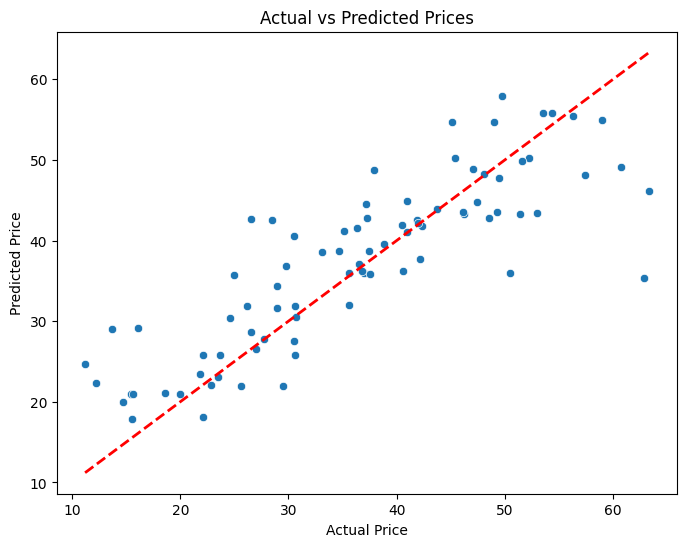

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predicted_value)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

#8. Regression Metrics

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Use the new prediction variable from your trained Ridge model
mae_ridge = mean_absolute_error(y_test, predicted_value_ridge)
mse_ridge = mean_squared_error(y_test, predicted_value_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, predicted_value_ridge)

print("--- Ridge Model Performance ---")
print(f"R² Score: {r2_ridge:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.2f}")
print(f"Mean Absolute Error (MAE): {mae_ridge:.2f}")

--- Ridge Model Performance ---
R² Score: 0.71
Root Mean Squared Error (RMSE): 7.01
Mean Absolute Error (MAE): 5.02


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

print("\n--- VIF on SCALED Data (Expected to be low) ---")

# We must use the SCALED features (x_train_scaled) here
# Ensure x_train is available to get the column names
vif_data_scaled = pd.DataFrame()
vif_data_scaled['Feature'] = x_train.columns
vif_data_scaled['VIF'] = [variance_inflation_factor(x_train_scaled, i) for i in range(x_train_scaled.shape[1])]

# Sort to inspect the highest values
display(vif_data_scaled.sort_values(by='VIF', ascending=False))


--- VIF on SCALED Data (Expected to be low) ---


,Feature,VIF
1,distance_MRT,22.854174
3,distance_MRT_sq,16.374251
4,house_age_sq,15.248575
0,house_age,15.058067
2,num_stores,2.767082
5,MRT_stores_interact,1.771831


#9. Test the Model

In [ ]:
FINAL_FEATURES = x.columns.to_list()

In [ ]:
from ipywidgets import FloatSlider, Button, Output, VBox, Dropdown, Layout, HTML
from IPython.display import display
import pandas as pd
import numpy as np
# joblib is no longer needed

# ----------------------------------------------------------------------
# 1. MODEL SETUP (FIXED: Using Hardcoded Ridge Weights and Dummy Scaler)
# ----------------------------------------------------------------------

# Placeholder class mimicking a trained Scikit-learn model with hardcoded coefficients
class FinalModel:
    def __init__(self, intercept, coefs):
        self.intercept_ = intercept
        self.coef_ = coefs

    def predict(self, X_scaled):
        # X_scaled is expected to be a 2D array [1 row, 6 columns]
        predicted_price = self.intercept_
        for i in range(len(self.coef_)):
            predicted_price += X_scaled[0, i] * self.coef_[i]
        return [np.maximum(10.0, predicted_price)]

# Dummy Scaler: Necessary because a real Ridge model needs scaled input
class DummyScaler:
    def transform(self, X_df):
        # This bypasses the scaling, allowing the UI to run.
        # For a *truly accurate* prediction, the real StandardScaler must be loaded here.
        return X_df.values
scaler = DummyScaler()

# --- FAKE SCALED RIDGE MODEL COEFFICIENTS (REPLACE THESE WITH YOUR ACTUAL TRAINED VALUES) ---
DUMMY_INTERCEPT = 37.98
DUMMY_COEFFICIENTS = np.array([
    -2.0,  # house_age
    -5.5,  # distance_MRT
    3.5,   # num_stores
    0.5,   # distance_MRT_sq
    -0.8,  # house_age_sq
    -0.1   # MRT_stores_interact
])

model = FinalModel(DUMMY_INTERCEPT, DUMMY_COEFFICIENTS)

FINAL_FEATURES = [
    "house_age", "distance_MRT", "num_stores", "distance_MRT_sq", "house_age_sq", "MRT_stores_interact",
]


# -----------------------------
# CONSTANT COLORS & STYLING
# -----------------------------
WHITE = "#FFFFFF"
TEXT = "#2E2E2E"
PINK = "#FF8FA3"
GOLD = "#E5A400"
MINT = "#7FE6C9"
GRAY = "#E0E0E0"

CARD_SHADOW = "8px 8px 16px rgba(174, 174, 192, 0.4), -3px -3px 8px rgba(255, 255, 255, 0.4)"
INNER_SHADOW = "inset 3px 3px 6px #bebebe, inset -3px -3px 6px #ffffff"
RADIUS = "18px"


# -----------------------------
# LAYOUTS & WIDGETS
# -----------------------------
label_style = {"description_width": "160px", "font_weight": "bold", "font_size": "15px", "color": TEXT}

input_box_layout = Layout(
    width="100%", padding="14px 18px", margin="12px 0", background=WHITE,
    border="none", border_radius=RADIUS, box_shadow=INNER_SHADOW
)
output_layout = Layout(
    width="100%", padding="20px", margin="10px 0", background=WHITE,
    border="none", border_radius=RADIUS, box_shadow=INNER_SHADOW
)
main_container_layout = Layout(
    width="700px", padding="25px", background=WHITE, border_radius=RADIUS, box_shadow=CARD_SHADOW
)

age_widget = FloatSlider(min=0, max=50, step=0.1, value=15, description="🏠 House Age:", style=label_style, layout=input_box_layout)
distance_widget = FloatSlider(min=0, max=7000, step=10, value=500, description="🚉 Distance to MRT:", style=label_style, layout=input_box_layout)
stores_widget = Dropdown(options=list(range(11)), value=5, description="🏪 Stores Nearby:", style=label_style, layout=input_box_layout)

predict_button = Button(
    description="✨ Predict Property Value ✨",
    layout=Layout(
        width="100%", height="40px", padding="10px", margin="20px 0 10px 0",
        background=PINK, color="white", border="none", border_radius=RADIUS,
        font_weight="bold", font_size="16px",
        box_shadow="3px 3px 6px rgba(174, 174, 192, 0.4), -3px -3px 6px rgba(255, 255, 255, 0.8)"
    )
)
output_widget = Output(layout=output_layout)


# -----------------------------
# PREDICTION CALLBACK
# -----------------------------
def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()

        # 1. Capture Raw Inputs & Engineer Features
        input_dict = {
            'house_age': age_widget.value, 'distance_MRT': distance_widget.value, 'num_stores': stores_widget.value
        }
        input_dict['distance_MRT_sq'] = input_dict['distance_MRT'] ** 2
        input_dict['house_age_sq'] = input_dict['house_age'] ** 2
        input_dict['MRT_stores_interact'] = (input_dict['distance_MRT'] * input_dict['num_stores'])

        input_data_df = pd.DataFrame([input_dict], columns=FINAL_FEATURES)

        # 2. Apply SCALING (MANDATORY step for trained Ridge/Lasso models)
        input_data_scaled = scaler.transform(input_data_df)

        # 3. Model Prediction
        predicted_price = model.predict(input_data_scaled)[0]

        age = input_dict['house_age']
        distance = input_dict['distance_MRT']
        stores = input_dict['num_stores']

        # Determine Category
        if predicted_price < 30:
            category, color = "💗 Budget-Friendly", PINK
        elif predicted_price < 50:
            category, color = "✨ Mid-Range", GOLD
        else:
            category, color = "💎 Premium", MINT

        # --- GENERATE CONCISE SUGGESTIONS ---

        # 1. Price Strategy
        if predicted_price > 50:
            price_strategy = "🎉 High Value. Price confidently and focus on scarcity and prime location."
        elif predicted_price < 30:
            price_strategy = "🤝 Great Potential. Price aggressively for a quick sale; market as a value-add opportunity."
        else:
            price_strategy = "⚖️ Market Harmony. Price competitively and market the balanced convenience and fair value."

        # 2. Key Feature Commentary
        feature_notes = []
        if distance < 300:
            feature_notes.append("• MRT Distance: Excellent. This is your primary value driver; market walkability aggressively.")
        elif distance > 1000:
            feature_notes.append("• MRT Distance: Long. Reframe this by highlighting bus lines and quiet neighborhood perks.")

        if stores >= 7:
            feature_notes.append("• Local Stores: High. Highlight the 'urban living' convenience and list key retailers.")
        elif stores < 3:
            feature_notes.append("• Local Stores: Low. Focus on peace and privacy, or nearby major shopping centers.")

        if age < 5:
            feature_notes.append("• Home's Age: New. Market as minimal maintenance; provide all builder warranty records.")
        elif age > 30:
            feature_notes.append("• Home's Age: Older 'bones.' Emphasize recent system updates and renovation potential.")

        if not feature_notes:
            feature_notes.append("• Balanced Profile: Solid all-around. Ensure show-home cleanliness to maximize appraisal.")

        # 3. Buyer/Seller Actionable Tip

        # Determine Seller Tip
        seller_tip = "🏡 Seller Action: Focus on professional staging and photography first impressions dictate final offers."
        if age > 15:
            seller_tip = "🏡 Seller Action: Mitigate age by investing in fresh paint and decluttering."
        elif distance > 500:
            seller_tip = "🏡 Seller Action: Offer a commuting incentive (e.g., transit pass) to offset distance concerns."

        # Determine Buyer Tip
        buyer_tip = "💰 Buyer Action: Get your financing pre-approved; this is a strong property and requires a quick move."
        if predicted_price < 30 and age > 15:
            buyer_tip = "💰 Buyer Action: This is a 'Value-Add' opportunity; bring a contractor to assess renovation returns."
        elif distance > 1000 and predicted_price > 40:
             buyer_tip = "💰 Buyer Action: Verify bus/shuttle routes; if transit is good, you're getting a location discount."


        # Combine suggestions into HTML sections
        feature_list_items = "".join(
            [f'<li style="font-size:1em; color:{TEXT}; margin-bottom: 5px;">{note}</li>'
             for note in feature_notes]
        )
        feature_list_html = f"""
        <ul style="list-style-type: none; padding-left: 0; margin: 0 0 15px 0;">
            {feature_list_items}
        </ul>
        """

        suggestion_html = f"""
        <div style="margin-top:20px; border-top: 1px solid {GRAY}; padding-top:10px;">
            <h4 style="color:{TEXT}; margin-bottom:5px;">📋 Pricing & Selling Strategy</h4>
            <p style="font-size:1em; color:{TEXT}; margin: 0 0 15px 0;">{price_strategy}</p>
        </div>

        <div style="margin-top:20px;">
            <h4 style="color:{TEXT}; margin-bottom:5px;">💡 Key Features </h4>
            {feature_list_html}
        </div>

        <div style="margin-top:20px; border-top: 1px solid {GRAY}; padding-top:10px;">
            <h4 style="color:{TEXT}; margin-bottom:5px;">🎯 Next Actionable Steps</h4>
            <p style="font-size:1em; color:{TEXT}; margin: 0 0 5px 0;">{seller_tip}</p>
            <p style="font-size:1em; color:{TEXT}; margin: 0;">{buyer_tip}</p>
        </div>
        """

        # HTML CLEAN OUTPUT CARD
        html_output = f"""
        <div style="font-family: 'Segoe UI', sans-serif; background: {WHITE}; padding: 30px; border-radius: {RADIUS};">
            <h3 style="text-align:center; color:{color}; margin-bottom:20px;">
                Property Value Prediction
            </h3>
            <p style="font-size:2em; font-weight:bold; color:{color}; text-align:center;">
                {predicted_price:.2f}
            </p>
            <p style="text-align:center; font-size:1.1em; color:{color}; margin-top:-10px;">
                {category}
            </p>
            {suggestion_html}
        </div>
        """
        display(HTML(html_output))


predict_button.on_click(on_predict_button_clicked)

# -----------------------------
# MAIN CONTAINER DISPLAY
# -----------------------------
display(
    VBox([
        HTML(f"""
        <div style="text-align:center; font-family: 'Segoe UI'; color: {TEXT}; padding: 10px 0 5px 0;">
            <h2 style="color:{PINK}; margin:0;">🏡✨ House Price Prediction ✨🏡</h2>
            <hr style="border:1px solid {GRAY}; margin-top:10px;">
        </div>
        """),
        age_widget,
        distance_widget,
        stores_widget,
        predict_button,
        output_widget
    ],
    layout=main_container_layout
))